In [ ]:
import pickle
import numpy as np
import glob
import os

with open(
    "TRY6_UBT_to_T1_combined.pkl",
    "rb"
) as f:

    combined = pickle.load(f)
    

In [4]:
px = {}
py = {}
pz = {}
x = {}
y = {}
z = {}
# w = {}

for name in ["UBT", "T1"]:

    px[name] = combined[name]["px"]
    py[name] = combined[name]["py"]
    pz[name] = combined[name]["pz"]

    x[name] = combined[name]["x"]
    y[name] = combined[name]["y"]
    z[name] = combined[name]["z"]
    # w[name] = combined[name]["w"]

In [5]:
# Functions

def propagate_linear(x, y, px, py, pz, z0, z_new):
    """
    Linear transport of particles from z0 to z_new.

    Parameters
    ----------
    x, y : array-like
        Initial transverse positions.
    px, py, pz : array-like
        Momentum components.
    z0 : float
        Initial z position.
    z_new : float
        Target z position.

    Returns
    -------
    x_new, y_new : ndarray
        Transverse positions at z_new.
    """

    dz = z_new - z0

    # Avoid division problems for particles with pz ~ 0
    mask = np.abs(pz) > 0

    x_new = np.copy(x)
    y_new = np.copy(y)

    x_new[mask] += (px[mask] / pz[mask]) * dz
    y_new[mask] += (py[mask] / pz[mask]) * dz

    return x_new, y_new

def tapered_aperture(z):
    """
    Return the semi-apertures of the decay vessel.

    Parameters
    ----------
    z : float or ndarray
        Position along the beam line [m].

    Returns
    -------
    ax, ay : float or ndarray
        Semi-apertures in x and y [m].
    """

    z0 = 31          # vessel entrance [m]
    L = 50.0           # vessel length [m]

    z = np.asarray(z)

    # Relative coordinate along the vessel
    s = np.clip(z - z0, 0.0, L)

    ax = 0.5 + (2.0 - 0.5) * s / L
    ay = 2.7 + (6.0 - 2.7) * s / L

    return ax, ay

def detector_acceptance(x, y, z, layer):

    ax_det = layer["ax"]
    ay_det = layer["ay"]

    # Detector active area
    in_detector = (
        (np.abs(x) <= ax_det) &
        (np.abs(y) <= ay_det)
    )

    # Entrance tracker
    if layer["type"] == "entrance":
        return in_detector


    # Vessel aperture
    ax_vessel, ay_vessel = tapered_aperture(z)

    # Particle exits the vessel
    outside_vessel = (
        (np.abs(x) >= ax_vessel) |
        (np.abs(y) >= ay_vessel)
    )

    return in_detector & outside_vessel



In [6]:
# Detector Definition

DetectorTypes = {

    "A": {   # Straw tubes
        "name": "Straw",
        "cost_per_channel": 1.0,      # relative units
        "pitch": 0.010,               # 10 mm
        "sigma_x": 150e-6,            # 150 um
        "sigma_t": 2.0e-9,            # 2 ns
        "efficiency": 0.98,
    },

    "B": {   # Scintillating fibres
        "name": "Fiber",
        "cost_per_channel": 4.0,
        "pitch": 250e-6,              # 250 um
        "sigma_x": 70e-6,             # 70 um
        "sigma_t": 500e-12,           # 500 ps
        "efficiency": 0.995,
    },

    "C": {   # Silicon pixels
        "name": "Pixel",
        "cost_per_channel": 20.0,
        "pitch": 55e-6,               # 55 um
        "sigma_x": 10e-6,             # 10 um
        "sigma_t": 50e-12,            # 50 ps
        "efficiency": 0.999,
    }
}



In [7]:
# Function detector

def random_layout(n_layers, zmin=30.6, zmax=81):

    technologies = ["A","B","C"]

    layers=[]

    # -----------------------
    # entrance trackers
    # -----------------------

    for z in [30.7,30.8,30.9]:

        layers.append({

            "z":z,
            "technology":"A",

            "ax":2.1,
            "ay":1.35,

            "type":"entrance"
        })


    # -----------------------
    # lateral detectors
    # -----------------------
    if n_layers > 3:
        n_random = n_layers-3

        z_layers=np.sort(
            np.random.uniform(
                zmin,
                zmax,
                n_random
            )
        )


        for z in z_layers:

            vessel_ax,vessel_ay = tapered_aperture(z)


            # detector must be outside vessel
            margin_x=np.random.uniform(
                0.5,
                1
            )

            margin_y=np.random.uniform(
                0.5,
                1
            )


            layers.append({

                "z":z,

                "technology":
                    np.random.choice(technologies),

                "dx":
                    vessel_ax,

                "dy":
                    vessel_ay,

                # detector wall position
                "ax":
                    vessel_ax+margin_x,

                "ay":
                    vessel_ay+margin_y,

                "type":"lateral"

            })


    return sorted(
        layers,
        key=lambda x:x["z"]
    )

def simulate_layer(layer, x, y, px, py, pz, z0):

    tech = DetectorTypes[layer["technology"]]

    x_hit, y_hit = propagate_linear(
        x, y,
        px, py, pz,
        z0,
        layer["z"]
    )

    accepted = detector_acceptance(
        x_hit,
        y_hit,
        layer['z'],
        layer
    )

    detected = accepted & (
        np.random.rand(len(x_hit))
        < tech["efficiency"]
    )

    sigma = tech["sigma_x"]

    x_hit[detected] += np.random.normal(
        0,
        sigma,
        detected.sum()
    )

    y_hit[detected] += np.random.normal(
        0,
        sigma,
        detected.sum()
    )

    return {
        "z": layer["z"],
        "technology": layer["technology"],
        "mask": detected,
        "x": x_hit,
        "y": y_hit,
    }

def simulate_detector_system(layout,
                      x, y,
                      px, py, pz,
                      z0):

    all_hits = []
    for layer_id, layer in enumerate(layout):

        hits = simulate_layer(
            layer,
            x, y,
            px, py, pz,
            z0
        )

        mask = hits["mask"]

        for i in np.where(mask)[0]:

            all_hits.append({
                "particle": i,
                "layer": layer_id,
                "z": hits["z"],
                "x": hits["x"][i],
                "y": hits["y"][i],
                "technology": hits["technology"]
            })

    return all_hits

def detector_layer_cost(layer):

    tech = DetectorTypes[layer["technology"]]

    ax_det = layer["ax"]
    ay_det = layer["ay"]
    
    # Entrance trackers: full active area
    if layer["type"] == "entrance":

        area = (
            ax_det *
            ay_det
        )

    # Lateral detectors: remove vessel area
    elif layer["type"] == "lateral":

        ax_vessel, ay_vessel = tapered_aperture(
            layer["z"]
        )

        area = (
            (ax_det - ax_vessel) *
            (ay_det - ay_vessel)
        )

    #Account for the 4 quadrant
    area *=4
    
    # number of channels
    if tech["name"] == "Pixel":

        n_channels = (
            area /
            tech["pitch"]**2
        )

    else:

        n_channels = (
            area /
            tech["pitch"]
        )


    cost = (
        n_channels *
        tech["cost_per_channel"]
    )


    return cost, area


def evaluate_detector_cost(layout):

    total = 0

    print("\nDetector cost breakdown")

    for i, layer in enumerate(layout):

        cost, area = detector_layer_cost(layer)

        total += cost

        print(
            f"Layer {i:02d} | "
            f"{DetectorTypes[layer['technology']]['name']:6s} | "
            rf"Aperture = {layer['ax']- (layer['dx'] if 'dx' in layer.keys() else 0):.2f} m × {layer['ay']- (layer['dy'] if 'dx' in layer.keys() else 0):.2f} m | "
            rf"Sensitive Area = {area:.2f} m$^2$ | "
            f"Cost = {cost:.2f}"
        )


    print("----------------------------")
    print(
        f"Total detector cost = {total}"
    )

    return total

In [8]:
# Fit Tracks

def fit_track(z, x, y, z_target=82.0):
    """
    Fit a straight track and extrapolate to z_target.

    Parameters
    ----------
    z, x, y : array
        Hit coordinates.

    Returns
    -------
    dict
    """

    if len(z) < 2:
        return None

    bx, ax = np.polyfit(z, x, 1)
    by, ay = np.polyfit(z, y, 1)

    return {

        "ax": ax,
        "bx": bx,

        "ay": ay,
        "by": by,

        "x_target": ax + bx*z_target,
        "y_target": ay + by*z_target,

        "n_hits": len(z)

    }

In [9]:
# DOCA + IP definition
def line_from_track(track):

    point = np.array([
        track["ax"],
        track["ay"],
        0.0
    ])

    direction = np.array([
        track["bx"],
        track["by"],
        1.0
    ])

    direction /= np.linalg.norm(direction)

    return point, direction

def track_track_doca(track1, track2):

    p1, v1 = line_from_track(track1)
    p2, v2 = line_from_track(track2)

    w0 = p1 - p2

    a = np.dot(v1, v1)
    b = np.dot(v1, v2)
    c = np.dot(v2, v2)
    d = np.dot(v1, w0)
    e = np.dot(v2, w0)

    denom = a*c - b*b

    if np.abs(denom) < 1e-12:
        return None

    s = (b*e - c*d)/denom
    t = (a*e - b*d)/denom

    c1 = p1 + s*v1
    c2 = p2 + t*v2

    vertex = 0.5*(c1 + c2)

    doca = np.linalg.norm(c1 - c2)

    return doca, vertex

def impact_parameter(vertex, direction, origin=np.array([0., 0., 0.])):
    """
    Compute the impact parameter (IP) of a reconstructed HNL.

    Parameters
    ----------
    vertex : array-like, shape (3,)
        Reconstructed decay vertex.

    direction : array-like, shape (3,)
        Reconstructed HNL flight direction.
        (Does not need to be normalized.)

    origin : array-like, shape (3,), optional
        Production point (default = (0,0,0)).

    Returns
    -------
    ip : float
        Distance of closest approach between the HNL flight line
        and the production point.
    """

    direction = np.asarray(direction, dtype=float)
    direction /= np.linalg.norm(direction)

    vertex = np.asarray(vertex, dtype=float)
    origin = np.asarray(origin, dtype=float)

    return np.linalg.norm(
        np.cross(origin - vertex, direction)
    )

In [10]:
# Main
from itertools import combinations

def main(x, y, px, py, pz, z0, x_true, y_true, p_true, n_layers):

    # -----------------------------
    # 1. Create detector layout
    # -----------------------------
    layout = random_layout(n_layers)
    detector_cost = evaluate_detector_cost(layout)
    # print("Detector layout:")
    # for layer in layout:
    #     print(layer)


    # -----------------------------
    # 2. Simulate detector hits
    # -----------------------------
    all_hits = []

    all_hits =simulate_detector_system(layout,
                      x, y,
                      px, py, pz,
                      z0)
    print("\nTotal hits:", len(all_hits))

    # -----------------------------
    # 3. Collect hits per particle
    # -----------------------------
    particle_hits = {}

    for hit in all_hits:

        pid = hit["particle"]

        if pid not in particle_hits:
            particle_hits[pid] = []

        particle_hits[pid].append(hit)
        
    # -----------------------------
    # 4. Fit tracks
    # -----------------------------
    tracks = {}
    accepted_tracks = {}
    rejected_tracks = {}

    for pid, hits in particle_hits.items():

        if len(hits) < 3:
            continue

        z_hits = np.array(
            [h["z"] for h in hits]
        )

        x_hits = np.array(
            [h["x"] for h in hits]
        )

        y_hits = np.array(
            [h["y"] for h in hits]
        )

        
        track = fit_track(
            z_hits,
            x_hits,
            y_hits,
            z_target=82.0
        )
        inside_T1 = (
            (np.abs(track["x_target"]) <= 2) &
            (np.abs(track["y_target"]) <= 3)
        )

        if not inside_T1:
            rejected_tracks[pid] = track
            continue
        else:
            accepted_tracks[pid] = track
            tracks[pid] = track


    print("\nTotal tracks:", len(rejected_tracks) + len(accepted_tracks) )
    print("\nReconstructed tracks:", len(tracks))
    print("Accepted tracks:", len(accepted_tracks))
    print("Rejected tracks:", len(rejected_tracks))

    # Keep only rejected tracks with true momentum > 1 GeV/c
    tracks_list = [
        track
        for pid, track in rejected_tracks.items()
        if p_true[pid] > 1
    ]

    print("Rejected tracks with p > 1 GeV/c:", len(tracks_list))

    rejected_doca = []
    doca_candidates = []
    ip_values = []

    for t1, t2 in combinations(tracks_list, 2):

        result = track_track_doca(t1, t2)

        if result is None:
            continue

        doca, vertex = result

        # Statistics for ALL pairs
        rejected_doca.append(doca)

        # Only keep good HNL candidates
        if doca > 0.02:
            continue

        doca_candidates.append(doca)

        _, v1 = line_from_track(t1)
        _, v2 = line_from_track(t2)

        hnl_dir = v1 + v2
        hnl_dir /= np.linalg.norm(hnl_dir)

        ip = impact_parameter(vertex, hnl_dir)

        ip_values.append(ip)

    rejected_doca = np.asarray(rejected_doca)
    doca_candidates = np.asarray(doca_candidates)
    ip_values = np.asarray(ip_values)



    if len(rejected_doca):

        print("\nAll rejected-track pairs")
        print(f"Pairs       : {len(rejected_doca)}")
        print(f"Min DOCA    : {np.min(rejected_doca)*100:.2f} cm")
        print(f"Mean DOCA   : {np.mean(rejected_doca)*100:.2f} cm")
        print(f"Median DOCA : {np.median(rejected_doca)*100:.2f} cm")
        print(f"RMS DOCA    : {np.std(rejected_doca)*100:.2f} cm")

    if len(doca_candidates):

        print("\nDOCA < 2 cm candidates")
        print(f"Candidates  : {len(doca_candidates)}")
        print(f"Mean DOCA   : {np.mean(doca_candidates)*100:.2f} cm")
        print(f"Median DOCA : {np.median(doca_candidates)*100:.2f} cm")
        print(f"RMS DOCA    : {np.std(doca_candidates)*100:.2f} cm")

        print(f"Mean IP     : {np.mean(ip_values)*100:.2f} cm")
        print(f"Median IP   : {np.median(ip_values)*100:.2f} cm")
        print(f"Best IP     : {np.min(ip_values)*100:.2f} cm")


    # -----------------------------
    # 5. Compare with truth at z=82
    # -----------------------------
    residual_x = []
    residual_y = []

    for pid, track in tracks.items():

        residual_x.append(
            track["x_target"] - x_true[pid]
        )

        residual_y.append(
            track["y_target"] - y_true[pid]
        )

    residual_x = np.asarray(residual_x)
    residual_y = np.asarray(residual_y)

    print("\nReconstructed tracks:", len(tracks))
    

    if len(residual_x):

        print("\nTrack performance:")
        print(f"sigma x = {np.std(residual_x)*10**2:.4f} cm")
        print(f"sigma y = {np.std(residual_y)*10**2:.4f} cm")

    return {
        "layout": layout,
        "cost": detector_cost,
        "hits": all_hits,
        "tracks": tracks,
        "accepted_tracks": accepted_tracks,
        "rejected_tracks": rejected_tracks,
        "residual_x": residual_x,
        "residual_y": residual_y
    }

In [11]:
x0 = np.asarray(x["UBT"])
y0 = np.asarray(y["UBT"])

px0 = np.asarray(px["UBT"])
py0 = np.asarray(py["UBT"])
pz0 = np.asarray(pz["UBT"])

x_true, y_true = np.asarray(x["T1"]), np.asarray(y["T1"])
p_true = np.asarray(np.sqrt(px["T1"]**2+py["T1"]**2+pz["T1"]**2))
z0 = 30.6


In [12]:

result = main(
    x0,
    y0,
    px0,
    py0,
    pz0,
    z0,
    x_true, 
    y_true,
    p_true,
    10
)




Detector cost breakdown
Layer 00 | Straw  | Aperture = 2.10 m × 1.35 m | Sensitive Area = 11.34 m$^2$ | Cost = 1134.00
Layer 01 | Straw  | Aperture = 2.10 m × 1.35 m | Sensitive Area = 11.34 m$^2$ | Cost = 1134.00
Layer 02 | Straw  | Aperture = 2.10 m × 1.35 m | Sensitive Area = 11.34 m$^2$ | Cost = 1134.00
Layer 03 | Fiber  | Aperture = 0.78 m × 0.73 m | Sensitive Area = 2.27 m$^2$ | Cost = 36305.67
Layer 04 | Fiber  | Aperture = 0.73 m × 0.60 m | Sensitive Area = 1.75 m$^2$ | Cost = 28037.33
Layer 05 | Pixel  | Aperture = 0.68 m × 0.58 m | Sensitive Area = 1.60 m$^2$ | Cost = 10555321104.30
Layer 06 | Straw  | Aperture = 0.56 m × 0.85 m | Sensitive Area = 1.91 m$^2$ | Cost = 191.11
Layer 07 | Straw  | Aperture = 0.80 m × 0.69 m | Sensitive Area = 2.21 m$^2$ | Cost = 221.21
Layer 08 | Straw  | Aperture = 0.88 m × 0.51 m | Sensitive Area = 1.82 m$^2$ | Cost = 181.85
Layer 09 | Straw  | Aperture = 0.83 m × 0.83 m | Sensitive Area = 2.77 m$^2$ | Cost = 277.49
---------------------------

SEPARATE TASK

In [26]:
def find_vessel_intercepts(
    x0,
    y0,
    px,
    py,
    pz,
    z0=30.6,
    z_end=81.0,
    n_steps=1000
):

    n_muons = len(x0)

    z_grid = np.linspace(
        z0,
        z_end,
        n_steps
    )

    dz = z_grid[None, :] - z0

    # Vessel aperture at every z
    ax, ay = tapered_aperture(z_grid)

    ax = ax[None, :]
    ay = ay[None, :]

    # Propagate all muons to all z positions
    x_z = (
        x0[:, None]
        + (px / pz)[:, None] * dz
    )

    y_z = (
        y0[:, None]
        + (py / pz)[:, None] * dz
    )

    
    # Muon is outside the vessel
    outside = (
        (np.abs(x_z) <= ax)
        &
        (np.abs(y_z) <= ay)
    )

    # First position where the muon is outside
    has_intercept = outside.any(axis=1)

    first_index = np.argmax(
        outside,
        axis=1
    )

    # Initialize outputs
    z_intercept = np.full(
        n_muons,
        np.nan
    )

    x_intercept = np.full(
        n_muons,
        np.nan
    )

    y_intercept = np.full(
        n_muons,
        np.nan
    )

    # Store first interception point
    indices = np.where(has_intercept)[0]

    z_intercept[indices] = (
        z_grid[first_index[indices]]
    )

    x_intercept[indices] = (
        x_z[
            indices,
            first_index[indices]
        ]
    )

    y_intercept[indices] = (
        y_z[
            indices,
            first_index[indices]
        ]
    )

    return {
        "has_intercept": has_intercept,
        "z": z_intercept,
        "x": x_intercept,
        "y": y_intercept,
    }

In [27]:
intercepts = find_vessel_intercepts(
    x0,
    y0,
    px0,
    py0,
    pz0,
    z0=30.6,
    z_end=81.0,
    n_steps=1000
)

mask = intercepts["has_intercept"]

print(
    "Muons intersecting vessel:",
    np.sum(mask)
)

print(
    "Fraction:",
    np.mean(mask)
)

Muons intersecting vessel: 204094
Fraction: 0.77694155446174


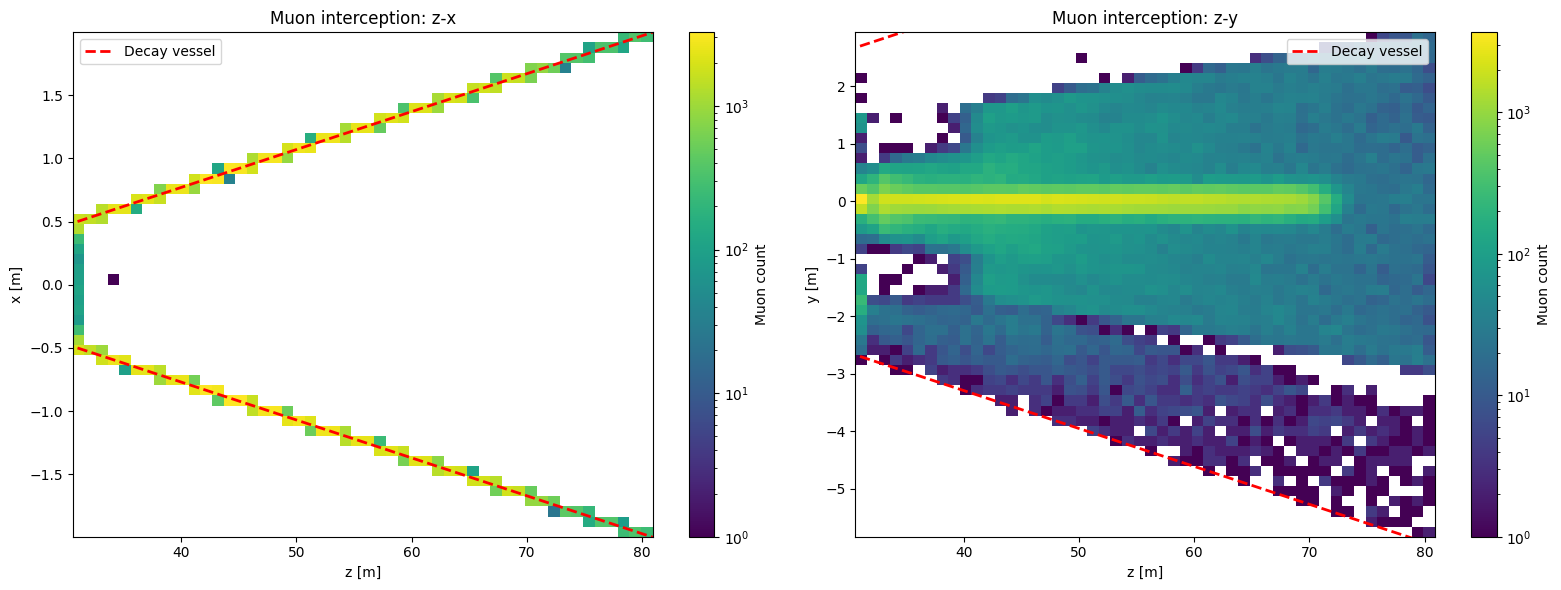

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# Vessel perimeter
# ============================================================

z_vessel = np.linspace(31, 81, 500)

ax_vessel, ay_vessel = tapered_aperture(z_vessel)


# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharex=True
)


# ============================================================
# z-x histogram
# ============================================================

h1 = axes[0].hist2d(
    intercepts["z"][mask],
    intercepts["x"][mask],
    bins=[50, 50],
    norm=LogNorm(),
    cmap="viridis"
)

# Vessel perimeter
axes[0].plot(
    z_vessel,
    +ax_vessel,
    "r--",
    linewidth=2,
    label="Decay vessel"
)

axes[0].plot(
    z_vessel,
    -ax_vessel,
    "r--",
    linewidth=2
)

axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("x [m]")
axes[0].set_title("Muon interception: z-x")
axes[0].legend()


# ============================================================
# z-y histogram
# ============================================================

h2 = axes[1].hist2d(
    intercepts["z"][mask],
    intercepts["y"][mask],
    bins=[50, 50],
    norm=LogNorm(),
    cmap="viridis"
)

# Vessel perimeter
axes[1].plot(
    z_vessel,
    +ay_vessel,
    "r--",
    linewidth=2,
    label="Decay vessel"
)

axes[1].plot(
    z_vessel,
    -ay_vessel,
    "r--",
    linewidth=2
)

axes[1].set_xlabel("z [m]")
axes[1].set_ylabel("y [m]")
axes[1].set_title("Muon interception: z-y")
axes[1].legend()


# ============================================================
# Colorbars
# ============================================================

fig.colorbar(
    h1[3],
    ax=axes[0],
    label="Muon count"
)

fig.colorbar(
    h2[3],
    ax=axes[1],
    label="Muon count"
)


plt.tight_layout()
plt.show()

SAVE FILE COMBINED

In [2]:
import pickle
import numpy as np
import glob
import os

folder = (
    "GNN_training/"
)

files = sorted(
    glob.glob(
        folder + "TRY6_UBT_to_T1_*.pkl"
    )
)

print(f"Found {len(files)} files")


# -----------------------------------
# Storage for both planes
# -----------------------------------

combined = {
    "UBT": {
        "px": [],
        "py": [],
        "pz": [],
        "x": [],
        "y": [],
        "z": [],
    },

    "T1": {
        "px": [],
        "py": [],
        "pz": [],
        "x": [],
        "y": [],
        "z": [],
    }
}


# -----------------------------------
# Load and concatenate all files
# -----------------------------------

for file in files:

    print(f"Loading: {os.path.basename(file)}")

    with open(file, "rb") as f:
        data = pickle.load(f)

    planes = data["planes"]

    for plane_id, name in enumerate(["UBT", "T1"]):

        plane = planes[plane_id]

        for key in combined[name]:

            combined[name][key].append(
                np.asarray(plane[key])
            )


# -----------------------------------
# Concatenate
# -----------------------------------

for name in ["UBT", "T1"]:

    for key in combined[name]:

        combined[name][key] = np.concatenate(
            combined[name][key]
        )

    print(
        f"{name}: "
        f"{len(combined[name]['x'])} muons"
    )


# -----------------------------------
# Save unique combined file
# -----------------------------------

output_file = (
    folder +
    "TRY6_UBT_to_T1_combined.pkl"
)

with open(output_file, "wb") as f:

    pickle.dump(
        combined,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )


print(f"\nSaved combined file to:")
print(output_file)

Found 200 files
Loading: TRY6_UBT_to_T1_0.pkl
Loading: TRY6_UBT_to_T1_1.pkl
Loading: TRY6_UBT_to_T1_10.pkl
Loading: TRY6_UBT_to_T1_100.pkl
Loading: TRY6_UBT_to_T1_101.pkl
Loading: TRY6_UBT_to_T1_102.pkl
Loading: TRY6_UBT_to_T1_103.pkl
Loading: TRY6_UBT_to_T1_104.pkl
Loading: TRY6_UBT_to_T1_105.pkl
Loading: TRY6_UBT_to_T1_106.pkl
Loading: TRY6_UBT_to_T1_107.pkl
Loading: TRY6_UBT_to_T1_108.pkl
Loading: TRY6_UBT_to_T1_109.pkl
Loading: TRY6_UBT_to_T1_11.pkl
Loading: TRY6_UBT_to_T1_110.pkl
Loading: TRY6_UBT_to_T1_111.pkl
Loading: TRY6_UBT_to_T1_112.pkl
Loading: TRY6_UBT_to_T1_113.pkl
Loading: TRY6_UBT_to_T1_114.pkl
Loading: TRY6_UBT_to_T1_115.pkl
Loading: TRY6_UBT_to_T1_116.pkl
Loading: TRY6_UBT_to_T1_117.pkl
Loading: TRY6_UBT_to_T1_118.pkl
Loading: TRY6_UBT_to_T1_119.pkl
Loading: TRY6_UBT_to_T1_12.pkl
Loading: TRY6_UBT_to_T1_120.pkl
Loading: TRY6_UBT_to_T1_121.pkl
Loading: TRY6_UBT_to_T1_122.pkl
Loading: TRY6_UBT_to_T1_123.pkl
Loading: TRY6_UBT_to_T1_124.pkl
Loading: TRY6_UBT_to_T1_125.pkl